LIBRARY


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

Load Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Path dataset
dataset_path = '/content/drive/My Drive/zoo/zoo.csv'
dataset = pd.read_csv(dataset_path)
dataset.head()

Mounted at /content/drive


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


Eksplorasi Data

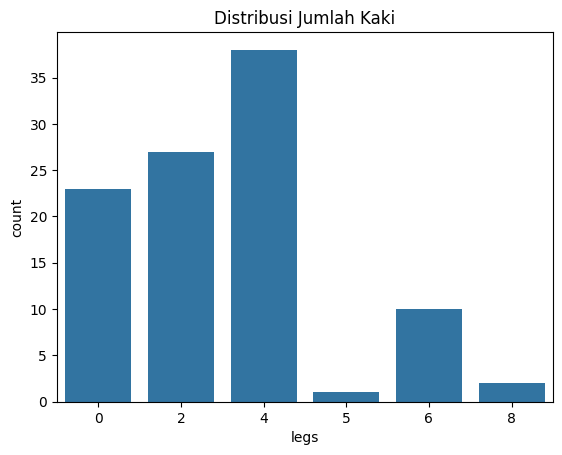

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   animal_name  101 non-null    object
 1   hair         101 non-null    int64 
 2   feathers     101 non-null    int64 
 3   eggs         101 non-null    int64 
 4   milk         101 non-null    int64 
 5   airborne     101 non-null    int64 
 6   aquatic      101 non-null    int64 
 7   predator     101 non-null    int64 
 8   toothed      101 non-null    int64 
 9   backbone     101 non-null    int64 
 10  breathes     101 non-null    int64 
 11  venomous     101 non-null    int64 
 12  fins         101 non-null    int64 
 13  legs         101 non-null    int64 
 14  tail         101 non-null    int64 
 15  domestic     101 non-null    int64 
 16  catsize      101 non-null    int64 
 17  class_type   101 non-null    int64 
dtypes: int64(17), object(1)
memory usage: 14.3+ KB


In [3]:
# Visualisasi distribusi jumlah kaki
sns.countplot(x='legs', data=dataset)
plt.title('Distribusi Jumlah Kaki')
plt.show()

# Informasi dataset
print("Informasi dataset:")
dataset.info()

Cleaning Data

Menghapus Duplikasi

In [4]:
print(f"Jumlah baris sebelum menghapus duplikat: {dataset.shape[0]}")
dataset.drop_duplicates(inplace=True)
print(f"Jumlah baris setelah menghapus duplikat: {dataset.shape[0]}")

Jumlah baris sebelum menghapus duplikat: 101
Jumlah baris setelah menghapus duplikat: 101


Mengatasi Missing Values

In [5]:
# Cek nilai kosong
print("Jumlah nilai kosong per kolom:\n", dataset.isnull().sum())

# Jika ada missing value, gunakan metode imputasi
dataset.fillna(method='ffill', inplace=True)

Jumlah nilai kosong per kolom:
 animal_name    0
hair           0
feathers       0
eggs           0
milk           0
airborne       0
aquatic        0
predator       0
toothed        0
backbone       0
breathes       0
venomous       0
fins           0
legs           0
tail           0
domestic       0
catsize        0
class_type     0
dtype: int64


<ipython-input-5-7979072504e7>:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dataset.fillna(method='ffill', inplace=True)


In [6]:
# Simpan dataset yang sudah bersih ke file CSV
cleaned_dataset_path = '/content/drive/My Drive/zoo_cleaned.csv'
dataset.to_csv(cleaned_dataset_path, index=False)

print(f"Dataset bersih telah disimpan di {cleaned_dataset_path}")

Dataset bersih telah disimpan di /content/drive/My Drive/zoo_cleaned.csv


Pra-Pemrosesan Data

Pisahkan Fitur dan Label

In [7]:
X = dataset.drop(columns=['animal_name', 'legs', 'class_type'])  # Drop kolom yang tidak diperlukan
y = dataset['legs']

Normalisasi Data

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Format Data untuk CNN (3D Tensor)

In [9]:
X_scaled_cnn = np.expand_dims(X_scaled, axis=-1)  # Tambahkan dimensi channel

Encode Label

In [10]:
y_encoded = to_categorical(y)

Split Data

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled_cnn, y_encoded, test_size=0.2, random_state=42)

Membuat Model CNN

In [12]:
model = Sequential([
    Conv1D(32, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Conv1D(64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(y_train.shape[1], activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Melatih Model

In [13]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.2406 - loss: 2.1243 - val_accuracy: 0.2381 - val_loss: 1.9350
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.3484 - loss: 1.9608 - val_accuracy: 0.3333 - val_loss: 1.7831
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.3305 - loss: 1.7937 - val_accuracy: 0.6667 - val_loss: 1.6403
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.4195 - loss: 1.6712 - val_accuracy: 0.6667 - val_loss: 1.5070
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.3914 - loss: 1.6112 - val_accuracy: 0.6667 - val_loss: 1.3816
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.3492 - loss: 1.5273 - val_accuracy: 0.6667 - val_loss: 1.2670
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4742 - loss: 1.4039 - val_accuracy: 0.6667 - val_loss: 1.1663
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5633 - loss: 1.3827 - val_accuracy: 0.7143 - val_loss: 1.0762
E

Evaluasi Model

In [14]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Akurasi pada data uji: {test_accuracy * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9524 - loss: 0.2891
Akurasi pada data uji: 95.24%


Visualisasi Hasil Pelatihan

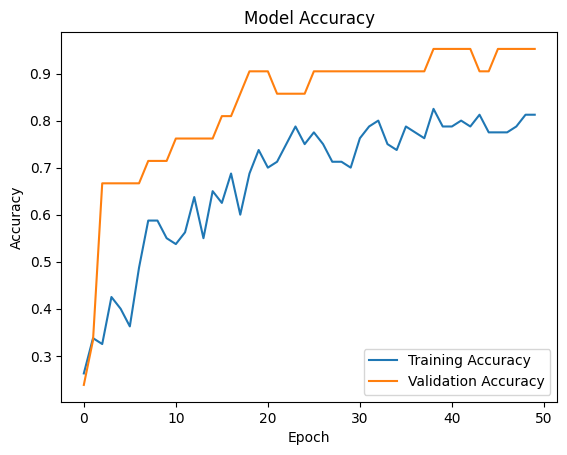

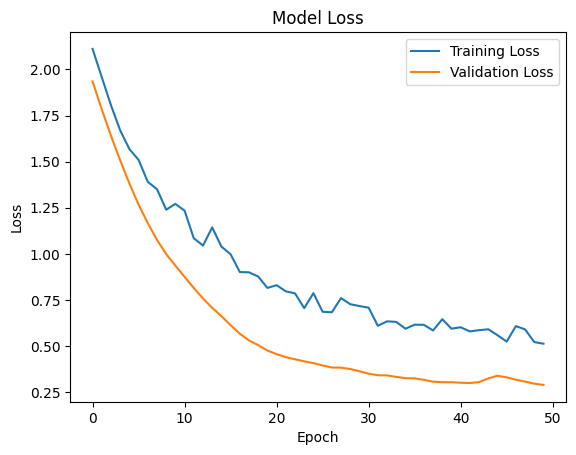

In [15]:
# Plot akurasi
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

Prediksi Data Baru

In [16]:
# Contoh prediksi untuk satu sample
sample_data = X_test[:1]  # Ambil satu sample dari data uji
prediksi = model.predict(sample_data)
print("Hasil prediksi (jumlah kaki):", np.argmax(prediksi))
print("Nilai sebenarnya:", np.argmax(y_test[:1]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step
Hasil prediksi (jumlah kaki): 4
Nilai sebenarnya: 2


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
Confusion Matrix:
 [[5 0 0 0]
 [0 3 1 0]
 [0 0 9 0]
 [0 0 0 3]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           2       1.00      0.75      0.86         4
           4       0.90      1.00      0.95         9
           6       1.00      1.00      1.00         3

    accuracy                           0.95        21
   macro avg       0.97      0.94      0.95        21
weighted avg       0.96      0.95      0.95        21


Accuracy: 0.9524
Precision: 0.9571
Recall: 0.9524
F1-Score: 0.9502


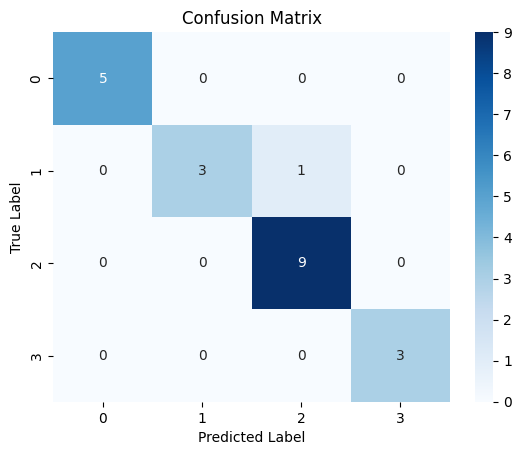

In [17]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

# Prediksi pada data uji
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Ubah prediksi ke kelas
y_true_classes = np.argmax(y_test, axis=1)  # Ubah label sebenarnya ke kelas

# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
print("Confusion Matrix:\n", cm)

# Classification Report
cr = classification_report(y_true_classes, y_pred_classes)
print("\nClassification Report:\n", cr)

# Metrik Evaluasi lainnya
accuracy = accuracy_score(y_true_classes, y_pred_classes)
precision = precision_score(y_true_classes, y_pred_classes, average='weighted')
recall = recall_score(y_true_classes, y_pred_classes, average='weighted')
f1 = f1_score(y_true_classes, y_pred_classes, average='weighted')

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Visualisasi Confusion Matrix (opsional)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()